<a href="https://colab.research.google.com/github/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/blob/main/1D_heat_ipinn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Solve an inverse problem for the 1D heat Equation with an unknown parameter alpha(a).

In [ ]:
pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.6 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd

In [ ]:
import deepxde as dde

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Enable just-in-time compilation with XLA.



In [ ]:
# Set the global random seed
dde.config.set_random_seed(42)

# Import our synthetic data

In [1]:
import os
import scipy.io
import numpy as np
import pandas as pd
import urllib.request

def get_data():
    file_path = '1D_Heat_Synthetic_Data.mat'

    if not os.path.isfile(file_path):
        print("Did not find", file_path)
        url = "https://github.com/AdityaWarrier2006/PINN-1D-Heat-Fourier_Law/raw/refs/heads/main/1D_Heat_Synthetic_Data.mat"
        urllib.request.urlretrieve(url, file_path)
        print("Downloaded file.")
    else:
        print("File already exists...")

    mat_data = scipy.io.loadmat(file_path)
    x = mat_data['x'].flatten()
    t = mat_data['t'].flatten()
    T = mat_data['T']

    X, Time = np.meshgrid(x, t, indexing='ij')
    df = pd.DataFrame({
        'x': X.flatten(), # Spatial grid array
        't': Time.flatten(), # Time grid array
        'T': T.flatten() # Target variable matrix, shape (len(x), len(t))
    })

    return x, t, T

In [3]:

x,t,T = get_data()

# Calculate grid spacing
dx = x[1] - x[0]
dt = t[1] - t[0]

File already exists...


Convert the data into a dataframe

In [4]:
# Create a 2D meshgrid for x and t
X, Time = np.meshgrid(x, t, indexing='ij')

# Flatten everything and construct the DataFrame
df = pd.DataFrame({
    'x': X.flatten(),
    't': Time.flatten(),
    'T': T.flatten()
})

In [5]:
# sample a 1000 random points only (for efficiency)
df_sampled = df.sample(n=1000, random_state=42)
print(df_sampled)
print(df_sampled.shape)

               x          t           T
10488   0.020202   2.799714   96.391758
450526  0.919192  18.508315   96.969090
71862   0.141414  13.255790   91.288943
440549  0.898990  17.794103   95.959254
372476  0.767677   0.000000   49.992325
...          ...        ...         ...
9377    0.010101  18.267524   99.607890
466770  0.959596   4.795429   94.085776
33163   0.060606  15.333129   96.875384
2011    0.000000   8.207326  100.000000
114916  0.232323   8.950107   79.328984

[1000 rows x 3 columns]
(1000, 3)


In [ ]:
# extract coordinates (x, t) and corresponding temperature (u_exact)

observe_x = df_sampled[['x', 't']].values
print(observe_x[5]) # print
print(observe_x.shape)

observe_u = df_sampled[['T']].values
print(observe_u[5])
print(observe_u.shape)

[ 0.23232323 10.79481686]
(1000, 2)
[82.77011144]
(1000, 1)


**In an inverse problem (like finding an unknown thermal conductivity $\alpha$ in the 1D heat equation):**



1.   The Physics-Informed
Neural Network (PINN) needs extra supervision beyond standard initial/boundary conditions to deduce the unknown parameter.

2.   PointSetBC treats these internal sensor measurements as additional boundary conditions/constraints in the loss function.



3. During training, DeepXDE penalizes the model whenever its prediction at observe_x deviates from observe_u, helping it back-calculate both the physical solution and the unknown PDE parameter ($\alpha$).





In [ ]:
# create a PointSet boundary condition for the inverse problem

observe_bc = dde.PointSetBC(observe_x, observe_u, component=0)

component=0: Specifies which output variable of the neural network is being constrained (0 refers to the first output component, which is temperature $T$ in your single-variable PDE).

## Define the system characteristics

Defien the PDE

In [ ]:
def pde(x, y):
    '''
    x: input tensor containing domain coordinates
    x[:,0] - spatial coordinates s
    x[:,1] - time coordinates t

    y: Network prediction for the target variable u(x, t)
    '''
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    # alpha = 0.01 the network has to figure this out

    '''
    i, j are the indexes of x and y respectively
    dy_t = dy/dt
    dy_xx = d2y/dx2
    '''
    # Force alpha to be positive during gradient updates
    return dy_t - tf.math.abs(alpha) * dy_xx

Define the spatial and temporal domain

In [ ]:
# Spatial domain: x in [0, 1]
# Time domain: t in [0, 20]
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 20)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)


Set an initial value to the unknown parameter **alpha**.

In [ ]:
alpha = dde.Variable(0.001)

Define the inital and boundary conditions

In [ ]:
# Boundary Condtion (Walls at x=0 and x=1 are at 100 degrees)
def boundary(x, on_boundary):
    return on_boundary and (np.isclose(x[0], 0.0) or np.isclose(x[0], 1.0))

bc = dde.icbc.DirichletBC(geomtime, lambda x: 100.0, boundary)

In [ ]:
def initial_smooth(x):
    # x[:, 0:1] extracts the spatial coordinates.
    # The exponentials create a steep gradient from 100 at the edges down to 25.
    x_pos = x[:, 0:1]
    return 25.0 + 75.0 * (np.exp(-150 * x_pos) + np.exp(-150 * (1 - x_pos)))

ic = dde.icbc.IC(geomtime, initial_smooth, lambda _, on_init: on_init)

In [ ]:
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic, observe_bc],
    num_domain=10000, # Increased for better spatial-temporal resolution
    num_boundary=500, # Increased to strictly enforce wall temperatures
    num_initial=500,  # Increased to capture the steep initial gradient
    train_distribution="Hammersley",
    anchors=observe_x
)

# Work the Neural Network

## Define the NN

In [ ]:
layer_size = [2] + [50]*4 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)
# Scale the [-1, 1] output to roughly match the 25 to 100 temperature range
net.apply_output_transform(lambda x, y: y * 37.5 + 62.5)

## Compile and train the NN

Set up hyperparameters

In [ ]:
lr = 0.001
loss_weights=[1, 1, 1, 100]
iterations = 15000

In [ ]:
model = dde.Model(data, net)

In [ ]:
# 1. Adam training
# The weights correspond to [PDE, BC, IC, Data]
model.compile("adam", lr, external_trainable_variables=alpha, loss_weights)
model.train(iterations, display_every=1000)

Compiling model...
'compile' took 0.040875 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7f1c516a3b00>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7f1c516a3b00>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                                  Test loss                                   Test metric
0         [6.74e+00, 1.16e+03, 1.94e+03, 3.35e+04]    [6.74e+00, 1.16e+03, 1.94e+03, 3.35e+04]    []  
1000      [8.09e+01, 1.35e+01, 5.46e+02, 2.30e+02]    [8.09e+01, 1.35e+01, 5.46e+02, 2.30e+02]    []  
2000      [9.28e+01, 9.96e+00, 4.97e+02, 1.82e+02]    [9.28e+01, 9.96e+00, 4.97e+02, 1.82e+02]    []  
3000      [1.00e+02, 8.98e+00, 4.44e+02, 1.66e+02]    [1.00e+02, 8.98e+00, 4.44e+02, 1.66e+02]   

(<deepxde.model.LossHistory at 0x7f1c518274d0>,
 <deepxde.model.TrainState at 0x7f1c51827380>)

In [ ]:
# 2. Add L-BFGS optimization for fine-tuning
model.compile("L-BFGS", external_trainable_variables=alpha)
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.001883 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
15000     [6.99e+01, 6.24e+00, 6.38e+01, 4.45e-01]    [6.99e+01, 6.24e+00, 6.38e+01, 4.45e-01]    []  
18524     [1.34e-01, 6.65e-03, 1.94e-01, 6.45e-01]    [1.34e-01, 6.65e-03, 1.94e-01, 6.45e-01]    []  

Best model at step 18524:
  train loss: 9.81e-01
  test loss: 9.81e-01
  test metric: []

'train' took 1370.837563 s



In [ ]:
print("Final alpha value:", alpha.numpy())

Final alpha value: 0.009754992


## Create a checkpoint and save the model

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


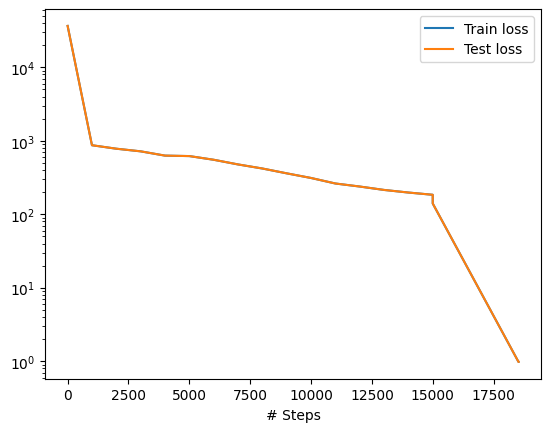

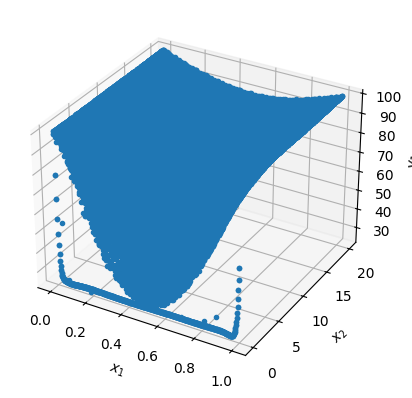

In [ ]:
# Save the model weights/checkpoints to a specific path
model.save("/content/my_ipinn_model_v1")

# This saves your loss history and training data as .dat files (which you saw in your output)
dde.saveplot(losshistory, train_state, issave=True, isplot=True)